In [26]:
import pandas as pd
drivers_data = pd.read_csv('drivers_data.csv')
drivers_data


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,...,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,0,13.3,3,0,0,...,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,0.0,38,0,13.3,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,0.0,40,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94375,345.6,0.0,6.6,7.0,0,0,14.5,6,0,0,...,-0.2,2,2.3,0.0,0.0,0,-13.2,2564,D,2
94376,345.6,0.0,6.6,7.0,0,0,14.5,6,0,0,...,0.1,2,8.7,0.0,-0.1,0,-13.0,2565,D,2
94377,345.6,0.0,6.6,7.0,0,0,14.5,6,0,0,...,-0.2,2,12.6,0.0,0.0,0,-13.2,2566,D,2
94378,332.8,0.0,5.7,6.3,0,0,14.1,6,0,0,...,-0.2,2,13.0,0.0,0.0,0,-13.3,2567,D,2


In [27]:
drivers_data.columns

Index(['Fuel_consumption', 'Accelerator_Pedal_value',
       'Throttle_position_signal', 'Short_Term_Fuel_Trim_Bank1',
       'Intake_air_pressure', 'Filtered_Accelerator_Pedal_value',
       'Absolute_throttle_position', 'Engine_soacking_time',
       'Inhibition_of_engine_fuel_cut_off', 'Engine_in_fuel_cut_off',
       'Fuel_Pressure', 'Long_Term_Fuel_Trim_Bank1', 'Engine_speed',
       'Engine_torque_after_correction', 'Torque_of_friction',
       'Flywheel_torque_(after_torque_interventions)', 'Current_spark_timing',
       'Engine_coolant_temperature', 'Engine_Idel_Target_Speed',
       'Engine_torque', 'Calculated_LOAD_value',
       'Minimum_indicated_engine_torque', 'Maximum_indicated_engine_torque',
       'Flywheel_torque', 'Torque_scaling_factor(standardization)',
       'Standard_Torque_Ratio', 'Requested_spark_retard_angle_from_TCU',
       'TCU_requests_engine_torque_limit_(ETL)',
       'TCU_requested_engine_RPM_increase',
       'Target_engine_speed_used_in_lock-up_modu

In [28]:
drivers_data.nunique()

Fuel_consumption                                  542
Accelerator_Pedal_value                           223
Throttle_position_signal                          206
Short_Term_Fuel_Trim_Bank1                         51
Intake_air_pressure                               158
Filtered_Accelerator_Pedal_value                    1
Absolute_throttle_position                        184
Engine_soacking_time                               10
Inhibition_of_engine_fuel_cut_off                   1
Engine_in_fuel_cut_off                              2
Fuel_Pressure                                       1
Long_Term_Fuel_Trim_Bank1                          16
Engine_speed                                     2965
Engine_torque_after_correction                    215
Torque_of_friction                                 58
Flywheel_torque_(after_torque_interventions)     1895
Current_spark_timing                              177
Engine_coolant_temperature                         89
Engine_Idel_Target_Speed    

In [29]:
corr_matrix = drivers_data.drop(columns=['Class']).corr()
print(corr_matrix)

                                              Fuel_consumption  \
Fuel_consumption                                      1.000000   
Accelerator_Pedal_value                               0.680555   
Throttle_position_signal                              0.815271   
Short_Term_Fuel_Trim_Bank1                           -0.004573   
Intake_air_pressure                                   0.631606   
Filtered_Accelerator_Pedal_value                           NaN   
Absolute_throttle_position                            0.823044   
Engine_soacking_time                                  0.018800   
Inhibition_of_engine_fuel_cut_off                          NaN   
Engine_in_fuel_cut_off                               -0.230997   
Fuel_Pressure                                              NaN   
Long_Term_Fuel_Trim_Bank1                            -0.212658   
Engine_speed                                          0.731023   
Engine_torque_after_correction                        0.884005   
Torque_of_

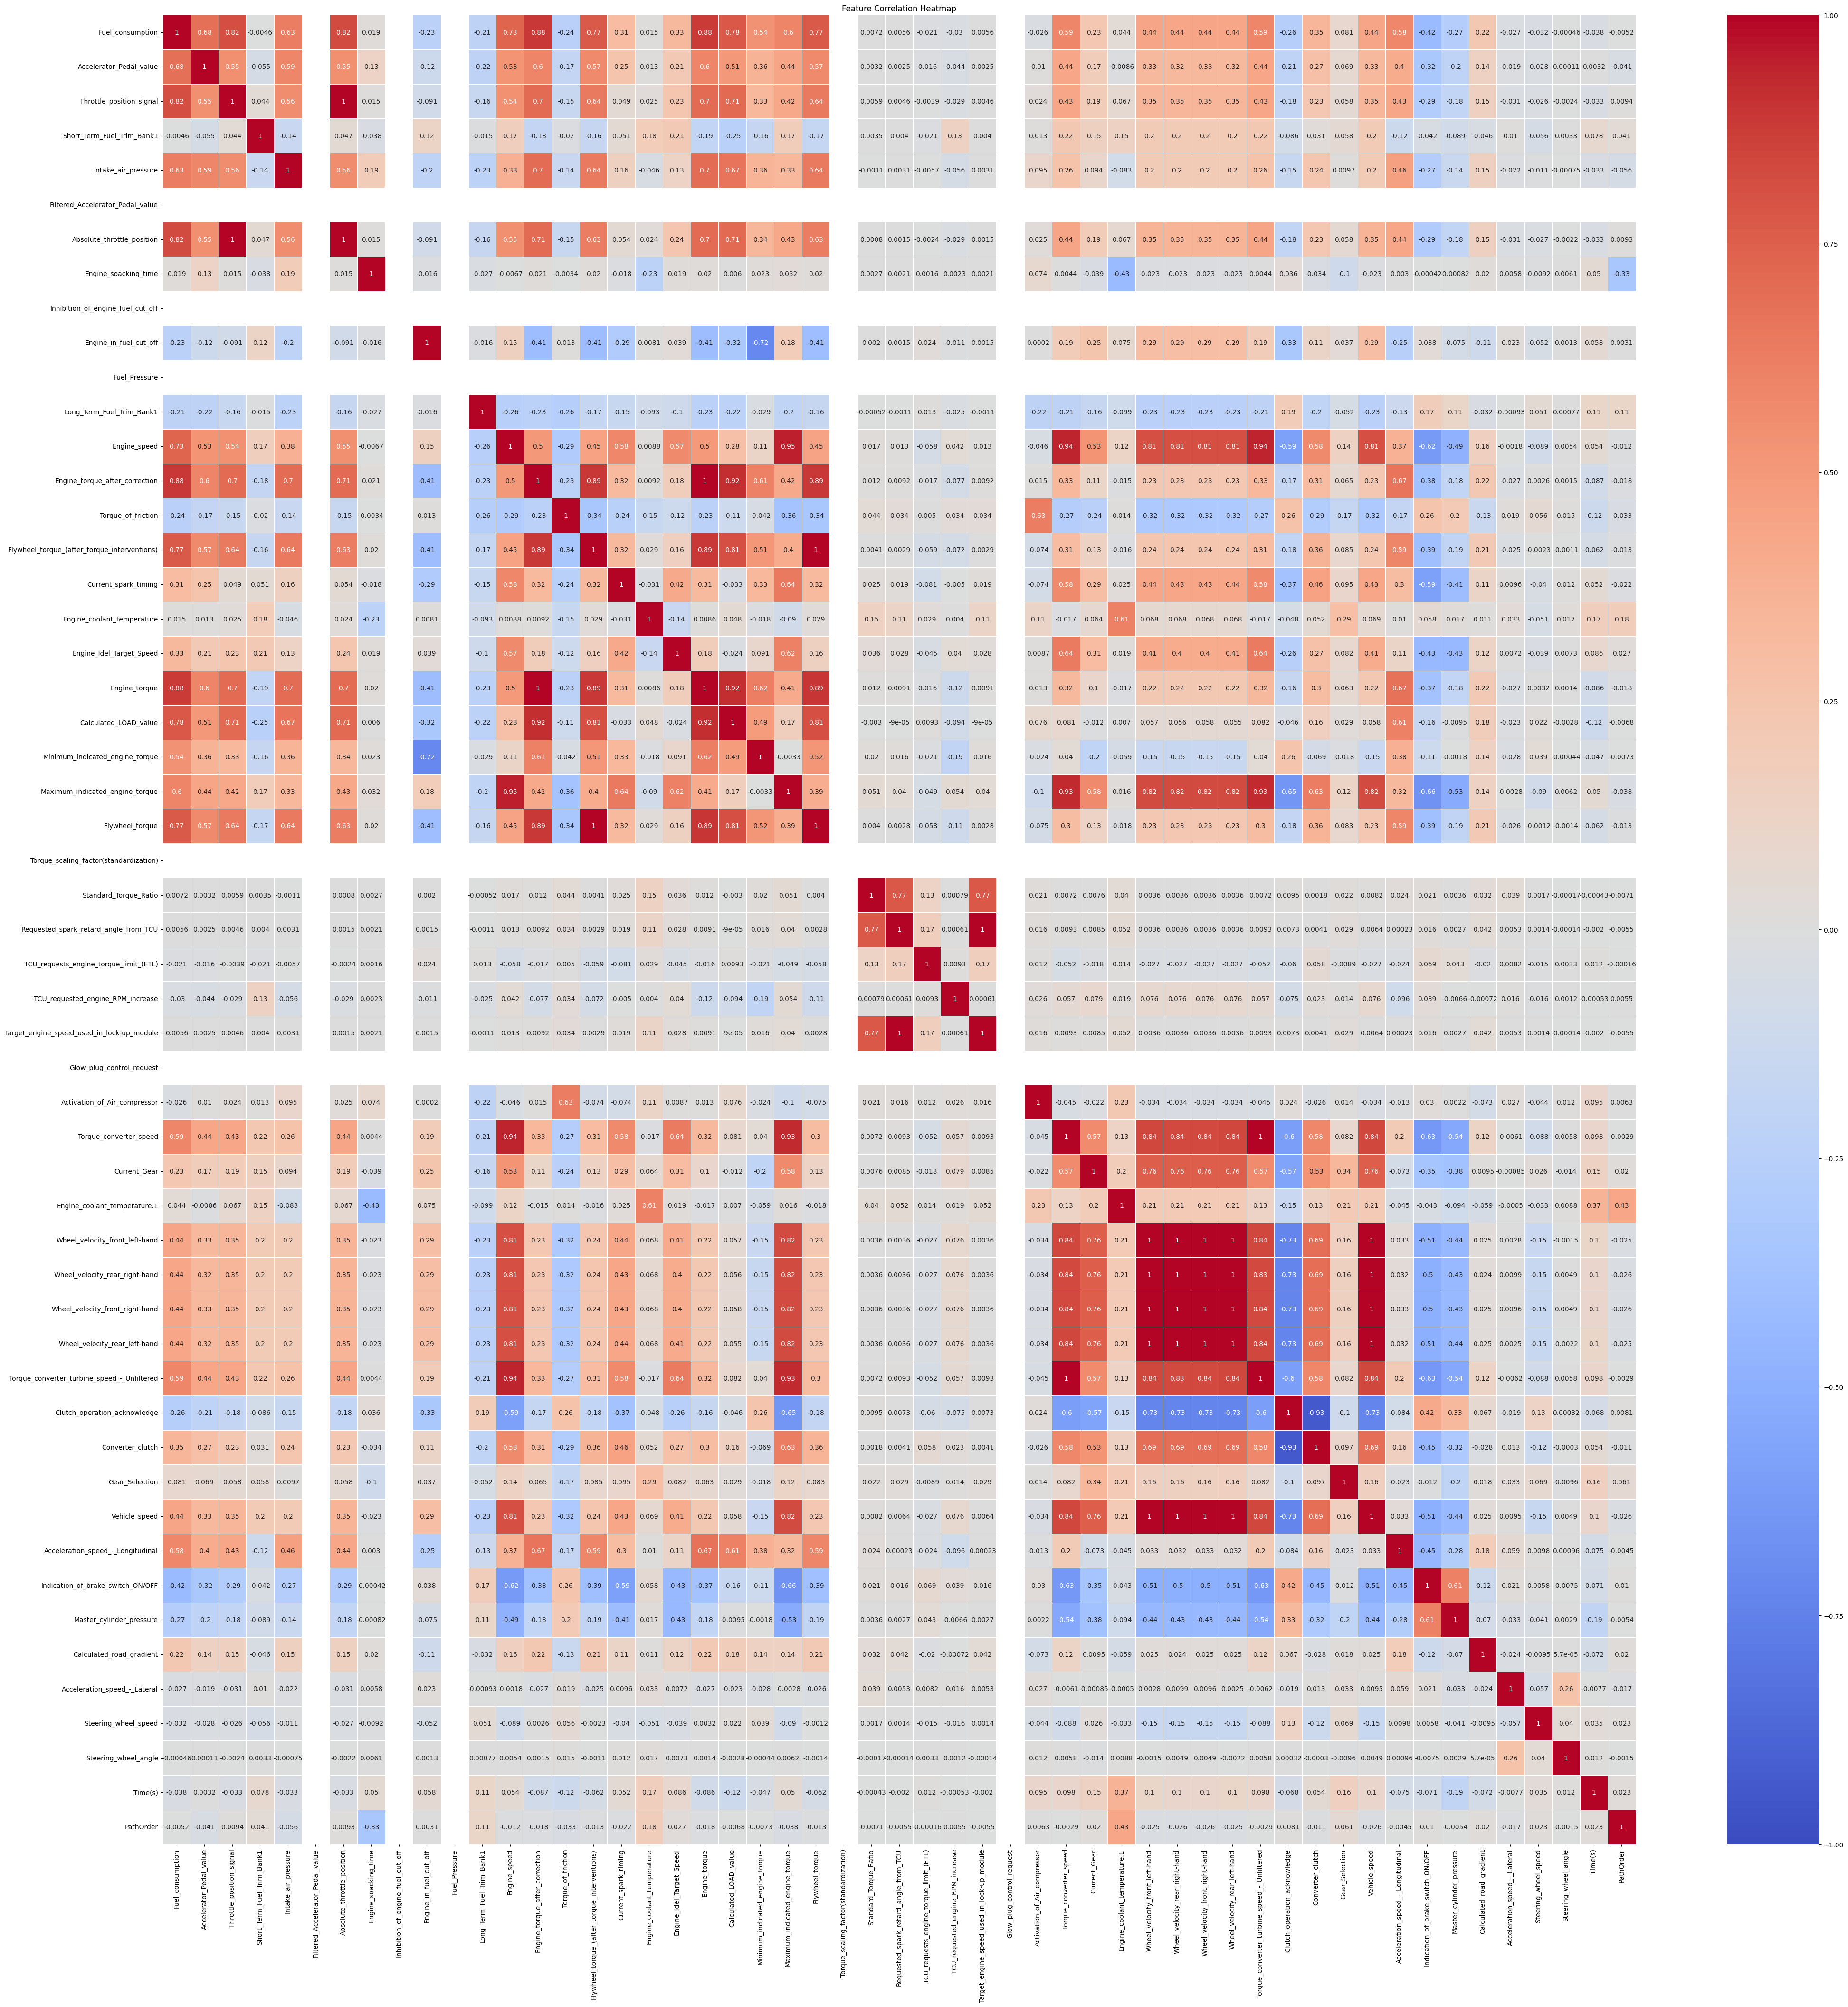

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = drivers_data.drop(columns=['Class']).corr()

# Set figure size
plt.figure(figsize=(50, 50))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation values
    cmap='coolwarm',   # color palette
    vmin=-1, vmax=1,   # correlation range
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [31]:
from sklearn.feature_selection import mutual_info_classif

X = drivers_data.drop(columns=['Class'])
y = drivers_data['Class']

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_scores)

Engine_soacking_time                            0.898533
Long_Term_Fuel_Trim_Bank1                       0.462902
Engine_coolant_temperature.1                    0.456999
Torque_of_friction                              0.231421
Intake_air_pressure                             0.184888
Maximum_indicated_engine_torque                 0.166731
Activation_of_Air_compressor                    0.100034
Master_cylinder_pressure                        0.091072
Steering_wheel_angle                            0.084663
Engine_coolant_temperature                      0.079717
Accelerator_Pedal_value                         0.074601
Absolute_throttle_position                      0.071830
Engine_torque                                   0.064814
Throttle_position_signal                        0.063534
Engine_torque_after_correction                  0.062790
Calculated_LOAD_value                           0.062627
Flywheel_torque_(after_torque_interventions)    0.058982
Wheel_velocity_front_right-hand

In [32]:
import numpy as np

# Υπολογισμός correlation matrix
corr_matrix = X.corr()

# Παίρνουμε μόνο το πάνω τρίγωνο για να μην έχουμε διπλές εγγραφές
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Εμφάνιση ζευγαριών με |corr| > 0.95
high_corr = upper_triangle.stack()

high_corr = high_corr[abs(high_corr) > 0.95]

print(high_corr)

Throttle_position_signal                      Absolute_throttle_position                     0.996340
Engine_speed                                  Maximum_indicated_engine_torque                0.951084
Engine_torque_after_correction                Engine_torque                                  0.998388
Flywheel_torque_(after_torque_interventions)  Flywheel_torque                                0.997655
Requested_spark_retard_angle_from_TCU         Target_engine_speed_used_in_lock-up_module     1.000000
Torque_converter_speed                        Torque_converter_turbine_speed_-_Unfiltered    0.999997
Wheel_velocity_front_left-hand                Wheel_velocity_rear_right-hand                 0.999840
                                              Wheel_velocity_front_right-hand                0.999842
                                              Wheel_velocity_rear_left-hand                  0.999990
                                              Vehicle_speed                       

In [33]:
drivers_data[['Engine_coolant_temperature', 'Engine_coolant_temperature.1']].corr()

,Engine_coolant_temperature,Engine_coolant_temperature.1
Engine_coolant_temperature,1.000000,0.611058
Engine_coolant_temperature.1,0.611058,1.000000


In [34]:
drivers_data.groupby('Class')['Engine_soacking_time'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
A,7240.0,57.716713,102.557677,0.0,4.0,4.0,6.0,255.0
B,12864.0,1.283271,1.731125,0.0,0.0,0.0,3.0,4.0
C,7500.0,71.168533,111.629945,0.0,2.0,6.0,255.0,255.0
D,13244.0,2.823920,1.803647,0.0,2.0,3.0,3.0,6.0
E,8436.0,85.096136,118.999567,0.0,2.0,3.0,255.0,255.0
F,11012.0,3.537595,3.784225,0.0,0.0,0.0,8.0,8.0
G,7492.0,2.445141,1.119031,0.0,1.0,2.0,3.0,4.0
H,9880.0,69.715182,105.825205,0.0,0.0,4.0,235.0,235.0
I,7808.0,3.855149,1.989507,0.0,2.0,3.0,7.0,7.0


In [35]:
drivers_data.groupby(['Class', 'PathOrder']).size()

Class  PathOrder
A      1            3196
       2            4044
B      1            6672
       2            6192
C      1            3948
       2            3552
D      1            6064
       2            7180
E      1            4412
       2            4024
F      1            5852
       2            5160
G      1            3516
       2            3976
H      1            4912
       2            4968
I      1            3712
       2            4096
J      1            3624
       2            5280
dtype: int64

<h1>Data Cleaning


In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


# ---------- Συνάρτηση IQR clipping (δεν διαγράφει γραμμές, "κόβει" τιμές) ----------
def iqr_clip(df, columns, factor=1.5):
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df[col] = df[col].clip(lower, upper)
    return df


# ---------- Στήλες προς αφαίρεση (ίδια λογική με πριν, με 2 διορθώσεις) ----------
to_drop = [
    'Filtered_Accelerator_Pedal_value', 'Glow_plug_control_request',
    'Inhibition_of_engine_fuel_cut_off', 'Fuel_Pressure',
    'Torque_scaling_factor(standardization)',
    'Target_engine_speed_used_in_lock-up_module', 'Converter_clutch', 'Clutch_operation_acknowledge',
    'TCU_requested_engine_RPM_increase', 'Indication_of_brake_switch_ON/OFF',
    'Standard_Torque_Ratio', 'Engine_in_fuel_cut_off',
    'TCU_requests_engine_torque_limit_(ETL)', 'Requested_spark_retard_angle_from_TCU',
    'Throttle_position_signal', 'Engine_speed', 'Flywheel_torque_(after_torque_interventions)',
    'Torque_converter_speed',
    # Wheel velocity: κρατάμε ΜΟΝΟ την 'rear_right' (το μεγαλύτερο MI score, 0.062,
    # ανάμεσα στις 4 σχεδόν-ταυτόσημες στήλες, corr > 0.999 μεταξύ τους)
    'Wheel_velocity_front_left-hand', 'Wheel_velocity_front_right-hand',
    'Wheel_velocity_rear_left-hand',
    # Το Time(s) δεν το χρειαζόμαστε πουθενά πια
    'Time(s)',
]


# ---------- Γενική συνάρτηση καθαρισμού ανά ομάδα κλάσεων ----------
def make_cleaned_dataset(raw_path, target_classes, out_path, to_drop, iqr_factor=1.5):
    drivers_data = pd.read_csv(raw_path)

    # Fix duplicate column names (π.χ. Engine_coolant_temperature)
    cols = pd.Series(drivers_data.columns)
    for dupe in cols[cols.duplicated()].unique():
        cols[cols == dupe] = [f"{dupe}_{i}" if i != 0 else dupe for i in range(sum(cols == dupe))]
    drivers_data.columns = cols

    drivers_data['Class'] = drivers_data['Class'].astype(str).str.strip().str.upper()

    # Φιλτράρισμα στις κλάσεις αυτής της ομάδας
    clean_df = drivers_data[drivers_data['Class'].isin(target_classes)].copy()

    # Αφαίρεση άχρηστων/redundant στηλών
    clean_df = clean_df.drop(columns=to_drop, errors='ignore')

    # IQR clipping μόνο στις αριθμητικές στήλες-features
    # (εξαιρούμε Class και PathOrder — δεν είναι μετρήσεις αισθητήρα)
    feature_cols = [c for c in clean_df.columns if c not in ['Class', 'PathOrder']]
    clean_df = iqr_clip(clean_df, feature_cols, factor=iqr_factor)

    # Encode Class -> 0,1,2,(3) ξεχωριστά για κάθε ομάδα
    le = LabelEncoder()
    if not clean_df.empty:
        clean_df['Class'] = le.fit_transform(clean_df['Class'])
        clean_df.to_csv(out_path, index=False)
        print(f"{out_path}: {len(clean_df)} rows, {clean_df.shape[1]} columns")
        print(f"  Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    return clean_df


# ---------- Παραγωγή των 3 datasets ----------
group_1 = ['A', 'B', 'C']
group_2 = ['D', 'E', 'F']
group_3 = ['G', 'H', 'I', 'J']

df1 = make_cleaned_dataset('drivers_data.csv', group_1, 'cleaned_1.csv', to_drop)
df2 = make_cleaned_dataset('drivers_data.csv', group_2, 'cleaned_2.csv', to_drop)
df3 = make_cleaned_dataset('drivers_data.csv', group_3, 'cleaned_3.csv', to_drop)

cleaned_1.csv: 27604 rows, 32 columns
  Mapping: {'A': 0, 'B': 1, 'C': 2}
cleaned_2.csv: 32692 rows, 32 columns
  Mapping: {'D': 0, 'E': 1, 'F': 2}
cleaned_3.csv: 34084 rows, 32 columns
  Mapping: {'G': 0, 'H': 1, 'I': 2, 'J': 3}
